# 🧬 1.3 Generador del Tensor AAontology z-scored

Este notebook construye el tensor **AAontology_zscored.pt**, que contiene los perfiles ontológicos/fisicoquímicos de los **20 aminoácidos** en **8 categorías**, normalizados por **z-score**. Este tensor es la base del enriquecimiento bioinformático que usan las capas `AAontologyMeanPooler` y `AAontologyGatedPooler`.

---

## 📋 Descripción general

El punto de partida es la matriz cruda de perfiles AAontology de forma `(20, 8)`:

- **Filas:** los 20 aminoácidos estándar.
- **Columnas:** las 8 categorías funcionales/fisicoquímicas de la ontología.

Flujo principal:
1. Carga de la matriz AAontology original.
2. Normalización por **z-score** (media 0, desviación 1) por columna.
3. Validación de rango y orden de los aminoácidos.
4. Serialización como tensor `AAontology_zscored.pt`.

El tensor resultante se utiliza después para ponderar residuos según su perfil ontológico, ya sea mediante *mean pooling* guiado o mediante *gating*.

---

## 🛠️ Funcionalidades principales

1. **Construcción del tensor**
   - Matriz `(20, 8)` con los perfiles AAontology.
   - Alineación consistente con el alfabeto de aminoácidos.

2. **Normalización z-score**
   - Estandarización por columna para que las categorías sean comparables.
   - Verificación de media ≈ 0 y desviación ≈ 1.

3. **Validación**
   - Chequeo de formas, valores finitos y orden de filas.
   - Impresión de estadísticas para control de calidad.

4. **Exportación**
   - Serialización en `AAontology_zscored.pt`.
   - Formato listo para ser cargado por los *poolers* ontológicos.

## 📦 1. Instalación de dependencias

In [ ]:
!pip install -q aaanalysis seaborn

## 🔧 2. Imports y configuración inicial

In [2]:
import torch
import pandas as pd
import numpy as np
import aaanalysis as aa
import matplotlib.pyplot as plt
import seaborn as sns
import os
import importlib.metadata

# --- Path ---
OUTPUT_PATH = '/kaggle/working/AAontology_zscored.pt'

AA_ORDER = list('ACDEFGHIKLMNPQRSTVWY')  # Orden canónico de los 20 aminoácidos estándar

# Categorías
ACTUAL_CATEGORIES = [
    'ASA/Volume',
    'Composition',
    'Conformation',
    'Energy',
    'Polarity',
    'Shape',
    'Structure-Activity',
    'Others',
]

## 📊 3. Carga de datos oficiales

In [3]:
df_scales = aa.load_scales(name='scales')      # Matriz (20 AA × ~586 escalas)
df_cat    = aa.load_scales(name='scales_cat')  # Metadata de categorías

print(f"✅ df_scales shape: {df_scales.shape}")
print(f"✅ df_cat shape   : {df_cat.shape}")
print(f"✅ Categorías disponibles: {df_cat['category'].unique().tolist()}\n")

✅ df_scales shape: (20, 586)
✅ df_cat shape   : (586, 5)
✅ Categorías disponibles: ['ASA/Volume', 'Composition', 'Conformation', 'Energy', 'Others', 'Polarity', 'Shape', 'Structure-Activity']



## ⚙️ 4. Pipeline de procesamiento y normalización

In [ ]:
def compute_aaontology_zscores(df_scales, df_cat, categories, aa_order=AA_ORDER):
    """
    Calcula el valor representativo por aminoácido (media de escalas) para cada categoría.
    Luego aplica z-score por columna usando NumPy nativo (más rápido y seguro).
    """
    col_means = []
    valid_cats = []

    for cat in categories:
        scale_ids = df_cat.loc[df_cat['category'] == cat, 'scale_id'].tolist()
        if not scale_ids:
            print(f"⚠️ Sin escalas para: {cat}")
            continue

        subset = df_scales.loc[aa_order, scale_ids]
        subset = subset.fillna(subset.mean())      # Rellena NaN por columna
        mean_per_aa = subset.mean(axis=1).values   # Shape: (20,)

        col_means.append(mean_per_aa)
        valid_cats.append(cat)
        print(f"✅ '{cat}': {len(scale_ids)} escalas procesadas")

    if not col_means:
        raise ValueError("No se encontraron escalas para ninguna categoría.")

    matrix = np.column_stack(col_means)  # Shape: (20, n_cats)
    
    mean = matrix.mean(axis=0)
    std = matrix.std(axis=0)
    std[std == 0] = 1.0  # Previene división por cero si una escala es constante
    zscored = (matrix - mean) / std

    return torch.tensor(zscored, dtype=torch.float32), valid_cats

## 🚀 5. Ejecución del pipeline

In [5]:
AAONTOLOGY_ZSCORED, USED_CATEGORIES = compute_aaontology_zscores(
    df_scales, df_cat, ACTUAL_CATEGORIES
)

print(f"\n📐 Tensor base shape (20 AAs): {AAONTOLOGY_ZSCORED.shape}")

✅ 'ASA/Volume': 64 escalas procesadas
✅ 'Composition': 58 escalas procesadas
✅ 'Conformation': 224 escalas procesadas
✅ 'Energy': 36 escalas procesadas
✅ 'Polarity': 111 escalas procesadas
✅ 'Shape': 45 escalas procesadas
✅ 'Structure-Activity': 31 escalas procesadas
✅ 'Others': 17 escalas procesadas

📐 Tensor base shape (20 AAs): torch.Size([20, 8])


## 💾 6. Integración del Token 'X' y Guardado

In [ ]:
# 1. Expandir lista de AAs para incluir 'X'
amino_acids = AA_ORDER.copy()
amino_acids.append('X')

num_aa = len(amino_acids)
num_cat = len(USED_CATEGORIES)

# 2. Inicializar tensor final (21, 8) en ceros
final_tensor = torch.zeros((num_aa, num_cat), dtype=torch.float32)

# 3. Copiar los z-scores de los 20 AAs estándar
final_tensor[:20, :] = AAONTOLOGY_ZSCORED
# La fila correspondiente a X se mantiene en cero 
# para representar padding/valores desconocidos 
# sin aportar características fisicoquímicas

# 4. Empaquetar y exportar
aa_version = importlib.metadata.version("aaanalysis")

data_to_save = {
    "tensor": final_tensor,
    "amino_acids": amino_acids,
    "categories": USED_CATEGORIES,
    "aaontology_version": aa_version, # Trazabilidad
}

os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True) if os.path.dirname(OUTPUT_PATH) else None
torch.save(data_to_save, OUTPUT_PATH)

print(f"✅ Tensor final guardado con shape ({num_aa}, {num_cat})")
print(f"💾 Guardado en: {OUTPUT_PATH}")

# Validación rápida
idx_x = amino_acids.index('X')
idx_l = amino_acids.index('L')
print(f"\n🔍 Validación interna:")
print(f"   Tensor 'L' (Leucina): {final_tensor[idx_l].tolist()}")
print(f"   Tensor 'X' (Padding): {final_tensor[idx_x].tolist()} (Debe ser todo ceros)")

✅ Tensor final guardado con shape (21, 8)
💾 Guardado en: /kaggle/working/AAontology_zscored.pt

🔍 Validación interna:
   Tensor 'L' (Leucina): [0.37219804525375366, 1.5524089336395264, -0.6076842546463013, -0.6159631609916687, 1.3347209692001343, -0.35584932565689087, 0.21614909172058105, 0.12377438694238663]
   Tensor 'X' (Padding): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] (Debe ser todo ceros)


## 👁️ 7. Verificación de integridad y Visualización (Heatmap)

🔄 Verificación tras recargar:
   Shape        : torch.Size([21, 8])
   Aminoácidos  : ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y', 'X']
   Categorías   : ['ASA/Volume', 'Composition', 'Conformation', 'Energy', 'Polarity', 'Shape', 'Structure-Activity', 'Others']
   AAontology v : 1.0.3
   min / max    : -2.498 / 2.210



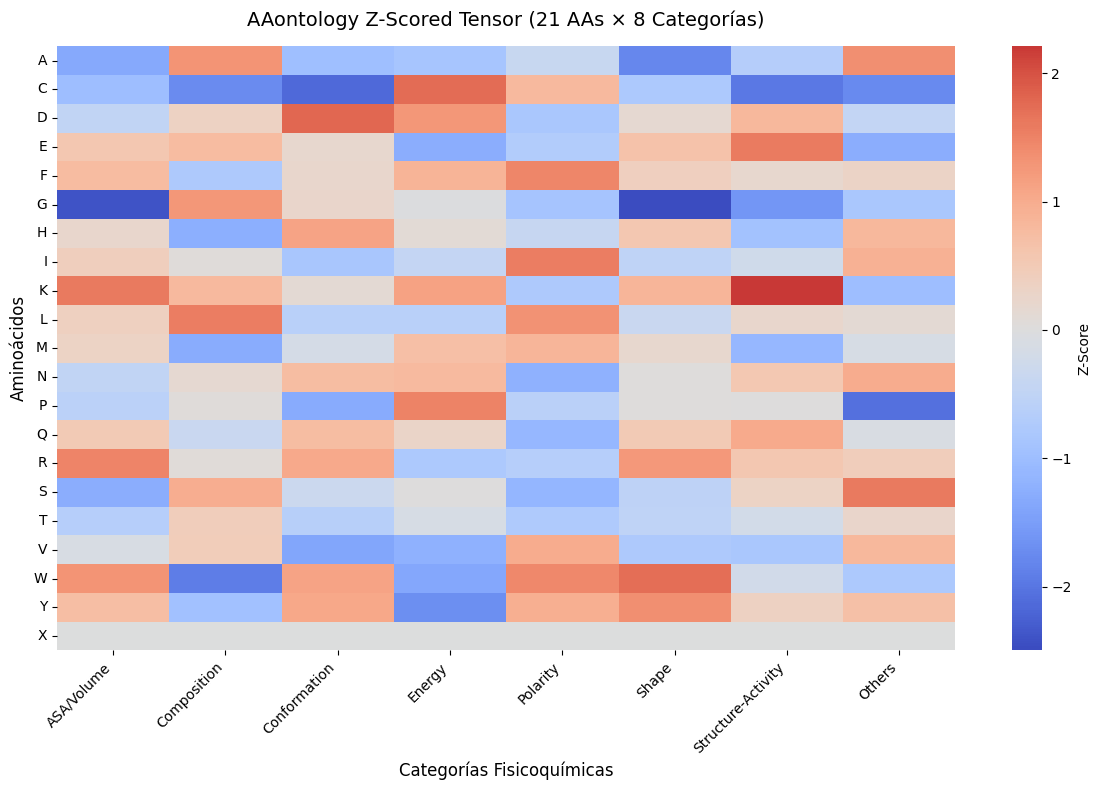


🔍 Preview numérico (primeros 5 AAs):


,ASA/Volume,Composition,Conformation,Energy,Polarity,Shape,Structure-Activity,Others
A,-1.321,1.312,-0.986,-0.876,-0.381,-1.795,-0.676,1.367
C,-1.005,-1.739,-2.136,1.747,0.807,-0.792,-1.978,-1.757
D,-0.487,0.337,1.789,1.274,-0.832,0.166,0.830,-0.459
E,0.558,0.761,0.200,-1.270,-0.699,0.657,1.583,-1.268
F,0.766,-0.760,0.210,0.880,1.463,0.405,0.200,0.299


In [7]:
# Recargar para asegurar que se guardó bien
data = torch.load(OUTPUT_PATH, map_location='cpu', weights_only=True)

print("🔄 Verificación tras recargar:")
print(f"   Shape        : {data['tensor'].shape}")
print(f"   Aminoácidos  : {data['amino_acids']}")
print(f"   Categorías   : {data['categories']}")
print(f"   AAontology v : {data.get('aaontology_version', 'Desconocida')}")
print(f"   min / max    : {data['tensor'].min().item():.3f} / {data['tensor'].max().item():.3f}\n")

# --- Visualización Gráfica ---
preview_df = pd.DataFrame(
    data['tensor'].numpy(),
    index=data['amino_acids'],
    columns=data['categories'],
).round(3)

plt.figure(figsize=(12, 8))
sns.heatmap(preview_df, cmap='coolwarm', center=0, annot=False, cbar_kws={'label': 'Z-Score'})
plt.title('AAontology Z-Scored Tensor (21 AAs × 8 Categorías)', fontsize=14, pad=15)
plt.xlabel('Categorías Fisicoquímicas', fontsize=12)
plt.ylabel('Aminoácidos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n🔍 Preview numérico (primeros 5 AAs):")
display(preview_df.head())

## 🏁 Resultado final: tensor AAontology_zscored.pt

El notebook genera y valida el tensor `AAontology_zscored.pt` de forma `(20, 8)`, con los perfiles ontológicos de los aminoácidos normalizados por z-score, listo para integrarse en las capas de *pooling* guiado del proyecto.

### Entregables

| Entregable | Forma | Descripción |
|---|---|---|
| `AAontology_zscored.pt` | `(20, 8)` | Perfiles AAontology z-normalizados |

### Análisis

- **Comparabilidad:** el z-score hace que las 8 categorías estén en la misma escala, evitando que una domine por magnitud.
- **Reutilización:** un único tensor precalculado sirve tanto a `AAontologyMeanPooler` como a `AAontologyGatedPooler`.
- **Trazabilidad:** la alineación fila→aminoácido garantiza que cada residuo reciba el perfil correcto durante el modelado.

**Estado final:** el tensor queda disponible en `/kaggle/input/.../AAontology_zscored.pt` para los notebooks de entrenamiento y validación que incorporan la ontología.